# Exercise 2. (Modern) Topic Modeling on News
In this exercise, we'll perform topic modeling on *document embeddings* using {cite:t}`kardos_turftopic_2025`'s [Turftopic](https://x-tabdeveloping.github.io/turftopic/) (aka the legend Márton)! 

> Note: Most of this tutorial is based on [Márton´s tutorial](https://x-tabdeveloping.github.io/turftopic/tutorials/arxiv_ml/). Highly recommend reading this after class to get the details :)


## Dataset & RQ
We'll use subset of a BBC news dataset from {cite:t}`li2024latesteval`. 

The news is inherently topical, often reflecting key events in the year. But, when looking back, my memory *can sometimes* exaggerate some stories or forget others entirely. Rather than trusting my memory, let's answer the question computationally:

```{admonition} RESEARCH QUESTION
What kinds of news topics were covered in April 2020 versus April 2025?
```

## 2.1 Install Packages
This time, let's install all necessary packages now:

In [160]:
%pip install datasets plotly sentence_transformers
%pip install "turftopic[umap-learn,datamapplot]" 
# installing turftopic with extra dependencies requires string format


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 2.2 Loading the Data
This time we'll use the `datasets` package from company "HuggingFace":

In [161]:
import datasets

:::{admonition} HANDS-ON
:class: red
Go and look at the [BBC dataset](https://huggingface.co/datasets/RealTimeData/bbc_news_alltime) on HuggingFace:

- On the Dataset Viewer, can you figure out how many subsets of the data there is? 
- What kinds of columns does the dataset have?
- Do you see any issues with the dataset? Any ethical concerns?
:::

We can load snippets as such:

In [162]:
ds_apr20 = datasets.load_dataset(
                            "RealTimeData/bbc_news_alltime", 
                            "2020-04" # subset of the data year: 2020, month: 04 (april)
                            )["train"] # there is only train, and we select this

Note: The `Dataset` class differs a little from a `pandas.DataFrame`, but works quite well with many newer workflows (for working wth `Transformers` which you'll learn about later!)

In [163]:
# print the ds 
print(ds_apr20)

Dataset({
    features: ['title', 'published_date', 'authors', 'description', 'section', 'content', 'link', 'top_image'],
    num_rows: 1152
})


Let's save all text to a `texts_apr20` variable:

In [164]:
texts_apr20 = ds_apr20["content"]
print(texts_apr20[1][:600])  # print first 600 characters of the 1st news article!

An "enormous strain" has been put on the system for obtaining protective kit for NHS staff and care workers, the education secretary has said.

Some 400,000 gowns had been expected to arrive from Turkey on Sunday, but the government said it had been delayed.

Gavin Williamson was asked by the BBC why British suppliers offering to make protective kit had not been contacted.

He responded that government hoped to speak to them within the next 24 hours, and the gowns should arrive on Monday.

"I think we all recognise the enormous strain that has been placed on the whole system and we also recogn


## 2.3 Embeddings with SentenceTransformers

We'll use a `Transformer` model, specifically trained for `embeddings` using the [SentenceTransformers](https://sbert.net/) package:

In [165]:
from sentence_transformers import SentenceTransformer

:::{admonition} LLM FRAMING: TRANSFORMERS? 
:class: fuchsia, dropdown
`Transformers` are the main architecture that almost all modern LLMs are built on. You'll learn more about what they are and how they work in a few weeks!

If you are impatient (:DD), you can read about them in [Jurafsky & Martin (2025), chapter 8](https://web.stanford.edu/~jurafsky/slp3/8.pdf).
:::

Let's initialize a model:

In [166]:
model_name = "all-MiniLM-L6-v2"  # a small, efficient model
encoder = SentenceTransformer(model_name)

We can now extract embeddings:

In [167]:
embeddings_apr20 = encoder.encode(texts_apr20, show_progress_bar=True)

Batches:   0%|          | 0/36 [00:00<?, ?it/s]

## 2.4 Extract Topic Data

We're ready to use the `turftopic` package, using a "flexible" ClusteringTopicModel

In [168]:
from turftopic import ClusteringTopicModel

Let's intialize the ClusteringTopicModel with its default model configuration:

In [169]:
model = ClusteringTopicModel()
print(model)

ClusteringTopicModel(clustering=HDBSCAN(min_cluster_size=25, min_samples=10),
                     dimensionality_reduction=TSNE(metric='cosine',
                                                   perplexity=15),
                     vectorizer=CountVectorizer(min_df=10,
                                                stop_words='english'))


/Users/au675000/Desktop/teaching/book.nosync/nlp-at-cogsci/.venv/lib/python3.12/site-packages/turftopic/models/cluster.py:133: UserWarning:

OpenTSNE is not installed, default scikit-learn implementation will be used.
        Your model could potentially run orders of magnitudes faster by installing openTSNE.
        



:::{admonition} QUESTION
:class: red
Look at the model configuration. Does anything look familiar here ;)?
:::

Let's fit the model:

In [170]:
model.fit(texts_apr20, embeddings=embeddings_apr20)

Output()

[22:30:14] Term extraction done.                                                                     ]8;id=439824;file:///Users/au675000/Desktop/teaching/book.nosync/nlp-at-cogsci/.venv/lib/python3.12/site-packages/turftopic/models/cluster.py\cluster.py]8;;\:]8;id=10062;file:///Users/au675000/Desktop/teaching/book.nosync/nlp-at-cogsci/.venv/lib/python3.12/site-packages/turftopic/models/cluster.py#481\481]8;;\

[22:30:16] Dimensionality reduction done.                                                            ]8;id=801389;file:///Users/au675000/Desktop/teaching/book.nosync/nlp-at-cogsci/.venv/lib/python3.12/site-packages/turftopic/models/cluster.py\cluster.py]8;;\:]8;id=899994;file:///Users/au675000/Desktop/teaching/book.nosync/nlp-at-cogsci/.venv/lib/python3.12/site-packages/turftopic/models/cluster.py#490\490]8;;\

           Clustering done.                                                                          ]8;id=455341;file:///Users/au675000/Desktop/teaching/book.nosync/nlp-at-cogsci/.venv/lib/python3.12/site-packages/turftopic/models/cluster.py\cluster.py]8;;\:]8;id=133838;file:///Users/au675000/Desktop/teaching/book.nosync/nlp-at-cogsci/.venv/lib/python3.12/site-packages/turftopic/models/cluster.py#493\493]8;;\

           Parameter estimation done.                                                                ]8;id=250672;file:///Users/au675000/Desktop/teaching/book.nosync/nlp-at-cogsci/.venv/lib/python3.12/site-packages/turftopic/models/cluster.py\cluster.py]8;;\:]8;id=73194;file:///Users/au675000/Desktop/teaching/book.nosync/nlp-at-cogsci/.venv/lib/python3.12/site-packages/turftopic/models/cluster.py#512\512]8;;\

           Model fitting done.                                                                       ]8;id=252205;file:///Users/au675000/Desktop/teaching/book.nosync/nlp-at-cogsci/.venv/lib/python3.12/site-packages/turftopic/models/cluster.py\cluster.py]8;;\:]8;id=981557;file:///Users/au675000/Desktop/teaching/book.nosync/nlp-at-cogsci/.venv/lib/python3.12/site-packages/turftopic/models/cluster.py#526\526]8;;\

,encoder,'sentence-transformers/all-MiniLM-L6-v2'
,vectorizer,CountVectoriz...rds='english')
,dimensionality_reduction,TSNE(metric='...perplexity=15)
,clustering,HDBSCAN(min_c...in_samples=10)
,feature_importance,'soft-c-tf-idf'
,n_reduce_to,None
,reduction_method,'average'
,reduction_distance_metric,'cosine'
,reduction_topic_representation,'component'
,random_state,None
,min_cluster_size,25


## 2.5 Looking at the topics!
Let's print the main topics, showing the highest 10 highest ranking words in each:

In [171]:
model.print_topics(top_k=10)

┏━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Topic ID ┃ Highest Ranking                                                                  ┃
┡━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       -1 │ said, people, uk, coronavirus, says, content, mr, twitter, bbc, year             │
├──────────┼──────────────────────────────────────────────────────────────────────────────────┤
│        0 │ league, players, premier, clubs, season, football, club, cut, sport, said        │
├──────────┼──────────────────────────────────────────────────────────────────────────────────┤
│        1 │ said, stores, retailers, sales, chain, shops, debenhams, firm, suppliers, retail │
├──────────┼──────────────────────────────────────────────────────────────────────────────────┤
│        2 │ 5g, app, users, said, theories, mobile, coronavirus, people, content, facebook   │
├──────────┼──────────────────────────────────────────────────────────────────────────────────┤
│        3 │ said, people, coronavirus, government, care, uk, health, bbc, mr, home           │
├──────────┼──────────────────────────────────────────────────────────────────────────────────┤
│        4 │ keir, shadow, sir, labour, party, said, leader, secretary, cup, team             │
└──────────┴──────────────────────────────────────────────────────────────────────────────────┘

:::{admonition} QUESTION
:class: red
Are the topics meaningful? What "title" would you give each?
:::

We can also plot this!

/Users/au675000/Desktop/teaching/book.nosync/nlp-at-cogsci/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_data.py:265: UserWarning:

Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.

/Users/au675000/Desktop/teaching/book.nosync/nlp-at-cogsci/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_data.py:284: UserWarning:

Numerical issues were encountered when scaling the data and might not be solved. The standard deviation of the data is probably very close to 0. 



<InteractiveFigure width=100% height=800>
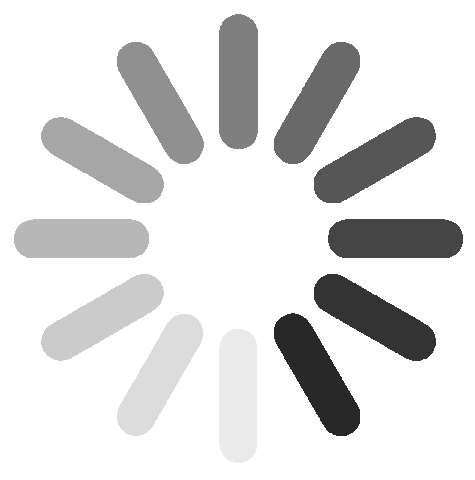

In [172]:
model.plot_clusters_datamapplot(hover_text=ds_apr20["title"]) # you can also write .write_html("myfile.html") to save it and view it better!

:::{admonition} QUESTION
:class: red
Consider the topics on the plot! Does it make it more meaningful to explore as a plot?
:::

### Your Turn: Run the workflow on 2025!
:::{admonition} HANDS-ON
:class: red
To practice the workflow, run it in your own notebook using the April 2025 subset:
- Load the dataset `ds_apr25`  
- Extract embeddings from `texts_apr25`  
- Run the topic model  
- Consider how the topics differ from 2017!
:::

## 2.6 Food for Thought: Differences Across Topic Models!
Just to consider differences, I want to show you the workflow on the 2020 data with the Top2Vec model (for mysterious reasons Top2Vec runs slowly on UCloud!)

In [173]:
from turftopic import Top2Vec

model = Top2Vec()
model.fit(texts_apr20, embeddings=embeddings_apr20)

Output()

[22:30:19] Term extraction done.                                                                     ]8;id=157903;file:///Users/au675000/Desktop/teaching/book.nosync/nlp-at-cogsci/.venv/lib/python3.12/site-packages/turftopic/models/cluster.py\cluster.py]8;;\:]8;id=559479;file:///Users/au675000/Desktop/teaching/book.nosync/nlp-at-cogsci/.venv/lib/python3.12/site-packages/turftopic/models/cluster.py#481\481]8;;\

[22:30:20] Dimensionality reduction done.                                                            ]8;id=640101;file:///Users/au675000/Desktop/teaching/book.nosync/nlp-at-cogsci/.venv/lib/python3.12/site-packages/turftopic/models/cluster.py\cluster.py]8;;\:]8;id=470537;file:///Users/au675000/Desktop/teaching/book.nosync/nlp-at-cogsci/.venv/lib/python3.12/site-packages/turftopic/models/cluster.py#490\490]8;;\

           Clustering done.                                                                          ]8;id=367713;file:///Users/au675000/Desktop/teaching/book.nosync/nlp-at-cogsci/.venv/lib/python3.12/site-packages/turftopic/models/cluster.py\cluster.py]8;;\:]8;id=195141;file:///Users/au675000/Desktop/teaching/book.nosync/nlp-at-cogsci/.venv/lib/python3.12/site-packages/turftopic/models/cluster.py#493\493]8;;\

[22:30:21] Parameter estimation done.                                                                ]8;id=578517;file:///Users/au675000/Desktop/teaching/book.nosync/nlp-at-cogsci/.venv/lib/python3.12/site-packages/turftopic/models/cluster.py\cluster.py]8;;\:]8;id=43038;file:///Users/au675000/Desktop/teaching/book.nosync/nlp-at-cogsci/.venv/lib/python3.12/site-packages/turftopic/models/cluster.py#512\512]8;;\

           Model fitting done.                                                                       ]8;id=263668;file:///Users/au675000/Desktop/teaching/book.nosync/nlp-at-cogsci/.venv/lib/python3.12/site-packages/turftopic/models/cluster.py\cluster.py]8;;\:]8;id=502105;file:///Users/au675000/Desktop/teaching/book.nosync/nlp-at-cogsci/.venv/lib/python3.12/site-packages/turftopic/models/cluster.py#526\526]8;;\

,encoder,'sentence-transformers/all-MiniLM-L6-v2'
,vectorizer,CountVectoriz...rds='english')
,dimensionality_reduction,UMAP(angular_...sable': True})
,clustering,HDBSCAN(min_cluster_size=15)
,feature_importance,'centroid'
,n_reduce_to,None
,reduction_method,'smallest'
,reduction_distance_metric,'cosine'
,reduction_topic_representation,'centroid'
,random_state,None
,min_cluster_size,15


Let's plot the topics:

/Users/au675000/Desktop/teaching/book.nosync/nlp-at-cogsci/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_data.py:265: UserWarning:

Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.



<InteractiveFigure width=100% height=800>
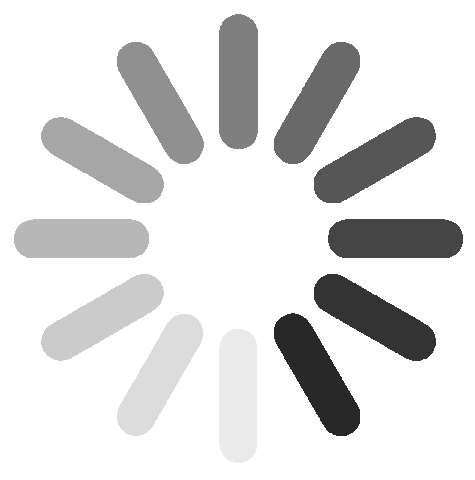

In [174]:
model.plot_clusters_datamapplot(hover_text=ds_apr20["title"])

:::{admonition} QUESTION
:class: red
How did the Top2Vec change the results?
:::

## 2.7 Explore TurfTopic's other tutorials
There are loads of diff. ways to approach topic modeling! 

We have just done the `Cluster Analysis` tutorial from TurfTopic, but there are three others on TurfTopic's [Tutorial Overview](https://x-tabdeveloping.github.io/turftopic/tutorials/overview/):  

:::{admonition} HANDS-ON
:class: red
1. Skim through the other 3 tutorials: [Discourse Analysis](https://x-tabdeveloping.github.io/turftopic/tutorials/religious/), [Dimensional Analysis](https://x-tabdeveloping.github.io/turftopic/tutorials/ideologies/), and [Dissatisfaction Analysis](https://x-tabdeveloping.github.io/turftopic/tutorials/reviews/).  
2. Consider whether there is an RQ that can be answered with methods from the tutorials above using our news data.  
3. Implement parts of one of the tutorials to address this RQ (or just play around with one of the tutorials!)
:::